## Adaptive RAG
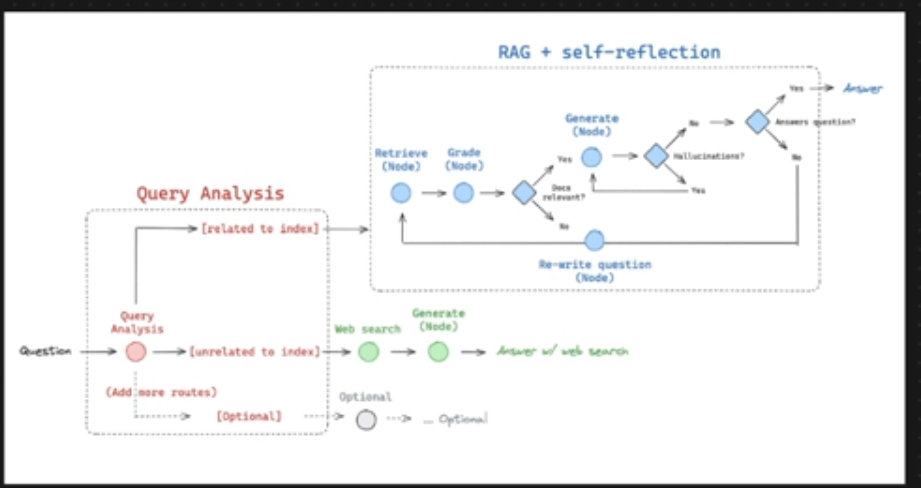

In [1]:
import os
from dotenv import load_dotenv
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from typing import TypedDict, List, Literal
from langgraph.graph import END, StateGraph, START
from langchain_tavily import TavilySearch
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [2]:
load_dotenv()

True

In [3]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else: 
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

In [4]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
        attempts: number of generation attempts
    """

    question: str
    generation: str
    documents: List[str]
    attempts: int


In [5]:
## All Pydantic models

class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource: Literal["vectorstore", "web_search"] = Field(description="Given a user question choose to route it to web search or a vectorstore.")

class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [6]:
# All Structured LLMS (Graders)
# --- Module-level setup ---
_llm = ChatOpenAI(model="gpt-4o", temperature=0)

_hallucination_grader = ChatPromptTemplate.from_messages([
    ("system", """You are a grader assessing whether an LLM generation is grounded in / 
    supported by a set of retrieved facts. Give a binary score 'yes' or 'no'. 'yes' means 
    that the answer is grounded in / supported by the set of facts."""),
    ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
]) | _llm.with_structured_output(GradeHallucinations)

_answer_grader = ChatPromptTemplate.from_messages([
    ("system", """You are a grader assessing whether an answer addresses / resolves a question.
    Give a binary score 'yes' or 'no'. 'yes' means that the answer resolves the question."""),
    ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
]) | _llm.with_structured_output(GradeAnswer)


_question_router = ChatPromptTemplate.from_messages([
    ("system", """You are an expert at routing a user question to a vectorstore or web search.
    The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
    Use the vectorstore for questions on these topics. Otherwise, use web-search."""),
    ("human", "{question}")
]) | _llm.with_structured_output(RouteQuery)


_rag_chain = ChatPromptTemplate.from_messages([
    (
        "human", """You are an assistant for question-answering tasks. 
        Use the following pieces of retrieved context to answer the question. 
        If you don't know the answer, just say that you don't know. 
        Use three sentences maximum and keep the answer concise.

        Question: {question} 

        Context: {context} 

        Answer:"""
    ) 
])| _llm | StrOutputParser()


_question_rewriter = ChatPromptTemplate.from_messages([
            ("system", """You a question re-writer that converts an input question to a better version that is optimized 
    for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""),
            ("human","Here is the initial question: \n\n {question} \n Formulate an improved question."),
]) | _llm | StrOutputParser()




_retrieval_grader = ChatPromptTemplate.from_messages([
        ("system", """You are a grader assessing relevance of a retrieved document to a user question.
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
]) | _llm.with_structured_output(GradeDocuments)

In [7]:
# Nodes
def web_search(state: GraphState):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state.get("documents", [])

    web_search_tool = TavilySearch(max_results=5)
    # Web search
    docs = web_search_tool.invoke({"query": question})
    # Join all result contents into a single string
    web_results = "\n\n".join(
        d["content"] for d in docs if "content" in d
    )

    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents}


def retrieve(state: GraphState) -> dict:
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Docs to index
    urls = [
        "https://lilianweng.github.io/posts/2023-06-23-agent/",
        "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
        "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
    ]

    loader = WebBaseLoader(web_paths=urls)
    docs = list(loader.lazy_load())

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500, 
        chunk_overlap=50
    )

    chunks = text_splitter.split_documents(docs)
    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vs.as_retriever()

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents}


def generate(state: GraphState) -> dict:
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    attempts = state.get("attempts", 0)  # get current attempt count, default 0

    # RAG generation
    generation = _rag_chain.invoke({"context": documents, "question": question})
    return {
        "generation": generation,
        "attempts": attempts + 1,  # increment attempt counter
    }



def transform_query(state: GraphState) -> dict:
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]

    # Re-write question
    better_question = _question_rewriter.invoke({"question": question})
    return {"question": better_question}


def grade_documents(state: GraphState) -> dict:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    
    for d in documents:
        score = _retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs}

In [8]:
# Max attempts before forcing an exit from any loop
MAX_ATTEMPTS = 3

# conditional functions
def route_question(state: GraphState) -> Literal['web_search', 'vectorstore']:

    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """
    
    print("---ROUTE QUESTION---")
    question = state["question"]

    source = _question_router.invoke({"question": question})

    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"
    else:
        raise ValueError("It has to be one of the following: vectorstore or web_search")
    


def grade_generation_v_documents_and_question(
    state: GraphState,
) -> Literal["useful", "not useful", "not supported"]:

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    attempts = state.get("attempts", 0)

    # Force exit if max attempts reached — return best answer we have
    if attempts >= MAX_ATTEMPTS:
        print(f"---MAX ATTEMPTS ({MAX_ATTEMPTS}) REACHED, STOPPING---")
        return "useful"

    hallucination_score = _hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )

    if hallucination_score.binary_score == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        print("---GRADE GENERATION vs QUESTION---")

        answer_score = _answer_grader.invoke(
            {"question": question, "generation": generation}
        )

        if answer_score.binary_score == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"

    print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
    return "not supported"
    

def decide_to_generate(state: GraphState) -> Literal["transform_query", "generate"]:
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    filtered_documents = state["documents"]
    attempts = state.get("attempts", 0)

    # Force exit to generate if max attempts reached
    if attempts >= MAX_ATTEMPTS:
        print(f"---MAX ATTEMPTS ({MAX_ATTEMPTS}) REACHED, FORCING GENERATE---")
        return "generate"

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"



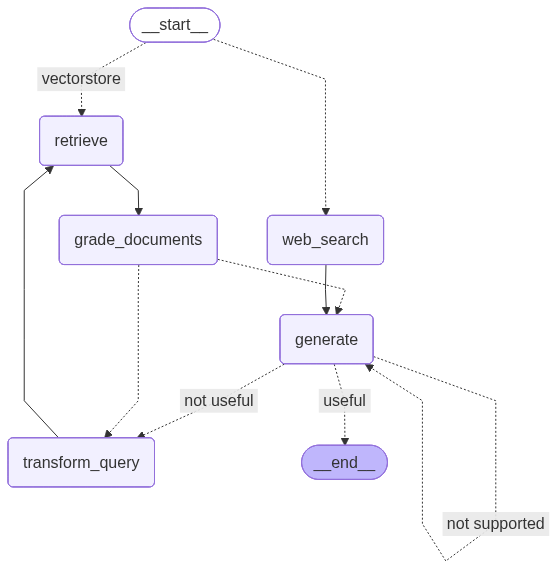

In [9]:
workflow = StateGraph(GraphState)

workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("grade_documents", grade_documents)  # grade documents


workflow.add_conditional_edges(
    START, 
    route_question, 
    {
        "web_search": "web_search", 
        "vectorstore": "retrieve"
    }
)

workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)

workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)
workflow.add_edge("transform_query", "retrieve")

# Compile
app = workflow.compile()
app

In [10]:
app.invoke({"question":"What is machine learning"})

---ROUTE QUESTION---


c:\Users\mrinm\Downloads\MyTraining\GenerativeAI\Retrieval_Augmented_Generation\RAG_Bootcamp_Udemy\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteQuery(datasource='web_search'), input_type=RouteQuery])
  return self.__pydantic_serializer__.to_python(


---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---


c:\Users\mrinm\Downloads\MyTraining\GenerativeAI\Retrieval_Augmented_Generation\RAG_Bootcamp_Udemy\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeHallucinations(binary_score='no'), input_type=GradeHallucinations])
  return self.__pydantic_serializer__.to_python(


---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---
---GENERATE---
---CHECK HALLUCINATIONS---
---MAX ATTEMPTS (3) REACHED, STOPPING---


{'question': 'What is machine learning',
 'generation': 'Machine learning is a subset of artificial intelligence that involves the use of algorithms and statistical models to enable computers to improve their performance on a task through experience. It allows systems to learn from data, identify patterns, and make decisions with minimal human intervention. Machine learning is used in various applications, such as recommendation systems, image recognition, and predictive analytics.',
 'documents': [Document(metadata={}, page_content='')],
 'attempts': 3}

In [11]:
app.invoke({"question":"What is agent memory"})

---ROUTE QUESTION---


c:\Users\mrinm\Downloads\MyTraining\GenerativeAI\Retrieval_Augmented_Generation\RAG_Bootcamp_Udemy\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteQuery(datasource='vectorstore'), input_type=RouteQuery])
  return self.__pydantic_serializer__.to_python(


---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---


c:\Users\mrinm\Downloads\MyTraining\GenerativeAI\Retrieval_Augmented_Generation\RAG_Bootcamp_Udemy\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(binary_score='yes'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(


---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---


...

---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---


c:\Users\mrinm\Downloads\MyTraining\GenerativeAI\Retrieval_Augmented_Generation\RAG_Bootcamp_Udemy\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeHallucinations(binary_score='yes'), input_type=GradeHallucinations])
  return self.__pydantic_serializer__.to_python(


---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


c:\Users\mrinm\Downloads\MyTraining\GenerativeAI\Retrieval_Augmented_Generation\RAG_Bootcamp_Udemy\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeAnswer(binary_score='yes'), input_type=GradeAnswer])
  return self.__pydantic_serializer__.to_python(


{'question': 'What is agent memory',
 'generation': 'Agent memory in the context of LLM-powered autonomous agents refers to the mechanisms that allow the agent to retain and recall information. It includes short-term memory, which involves in-context learning, and long-term memory, which enables the agent to store and retrieve information over extended periods using external vector stores. This memory system allows agents to learn from past experiences and improve their performance over time.',
 'documents': [Document(id='656bc327-daf7-467d-ba7b-623fe3da52e3', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and pro